# volbench: out-of-sample realized-volatility forecasting

**One question:** *out of sample, which volatility models actually win, and is the difference statistically real or just noise?*

Most volatility tutorials stop at fitting a GARCH and eyeballing the fit. This project answers the deployment question instead, and answers it rigorously: a strict look-ahead-free walk-forward, loss functions that are robust to a noisy variance proxy, and model-comparison tests (Diebold-Mariano, the Model Confidence Set, Clark-West) **built from scratch**, then applied across five asset classes.

**The headline:** a correctly specified **log-space HAR is hard to beat**. It stays in the 90% Model Confidence Set across eight equity indices, crypto, futures and FX, and machine learning does not displace it. That is a textbook result, reproduced carefully; the distinctive part is the breadth, the rigor, and an honest, pre-registered negative result on *where it stops winning*.

**How to read this notebook (top to bottom):** the data → the validated estimators → the from-scratch test machinery → the headline → a live walk-forward → whether ML wins → where it breaks → how a forecast turns into money → crypto → what I built.

> Full code, 245 tests and CI: [github.com/batuhanboztepe0/volbench](https://github.com/batuhanboztepe0/volbench). Research write-up: `report/volbench_report.tex`.

## 0. Setup

In [1]:
import json, inspect, pathlib
import numpy as np
import pandas as pd
import volbench
from IPython.display import Image, display

ROOT = pathlib.Path(volbench.__file__).resolve().parents[2]
RESULTS, FIGS = ROOT / "results", ROOT / "results" / "figures"

def show(name, width=820):
    display(Image(filename=str(FIGS / name), width=width))

def load(name):
    return json.loads((RESULTS / name).read_text())

print("volbench", getattr(volbench, "__version__", "?"), "| repo:", ROOT.name)

volbench 0.1.0 | repo: volbench


## 1. The data: 22 years of 5-minute realized volatility

Eight international equity indices from the Oxford-Man Realized Library, 2000-2022, about 5,000 trading days each. The two big spikes are the 2008 financial crisis and COVID, exactly when getting volatility right matters most.

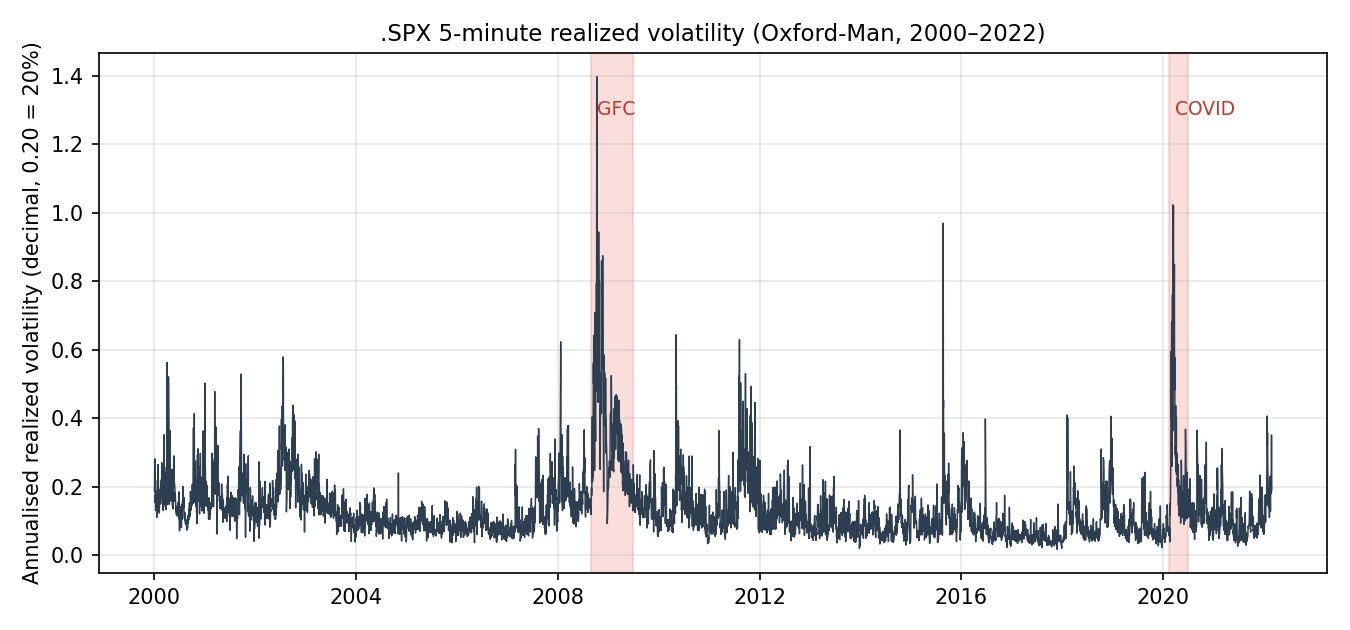

In [2]:
show('spx_realized_vol.png')

## 2. The estimators are validated, not assumed

Before forecasting anything, the realized estimators (bipower variation, median RV, the realized kernel, the BNS jump test) are checked against **simulated paths with known ground truth** (4,000 days). Each estimator recovers its target. The realized kernel is the punchline: under microstructure noise, naive realized variance is inflated roughly 3x at high frequency, while the kernel stays on the true quadratic variation.

In [3]:
v = load("validation.json")
val = pd.DataFrame([
    ["Realized variance / QV (clean)",        v["clean"]["rv_over_qv"],          1.0],
    ["Bipower / integrated var (clean)",       v["clean"]["bv_over_iv"],           1.0],
    ["Median RV / integrated var (clean)",     v["clean"]["medrv_over_iv"],        1.0],
    ["Bipower / IV (with jumps, finite-M bias)", v["jumps"]["bv_over_iv_with_jumps"], None],
    ["(RV - bipower) / jump variation",        v["jumps"]["rvminusbv_over_jv"],    1.0],
    ["Realized kernel / QV (clean)",           v["kernel_clean"]["rk_over_qv"],    1.0],
    ["Realized variance / QV (with noise)",    v["noisy"]["rv_over_qv"],           None],
    ["Realized kernel / QV (with noise)",      v["noisy"]["rk_over_qv"],           1.0],
    ["Jump-test false-positive rate @ 5%",     v["jump_test"]["false_positive_rate"], 0.05],
    ["Jump-test detection rate (injected)",    v["jump_test"]["detection_rate"],   None],
], columns=["check", "result", "target"]).round(3)
val

,check,result,target
0,Realized variance / QV (clean),1.000,1.00
1,Bipower / integrated var (clean),0.998,1.00
2,Median RV / integrated var (clean),0.998,1.00
3,"Bipower / IV (with jumps, finite-M bias)",1.044,NaN
4,(RV - bipower) / jump variation,0.926,1.00
5,Realized kernel / QV (clean),1.003,1.00
6,Realized variance / QV (with noise),2.997,NaN
7,Realized kernel / QV (with noise),1.008,1.00
8,Jump-test false-positive rate @ 5%,0.052,0.05
9,Jump-test detection rate (injected),0.938,NaN


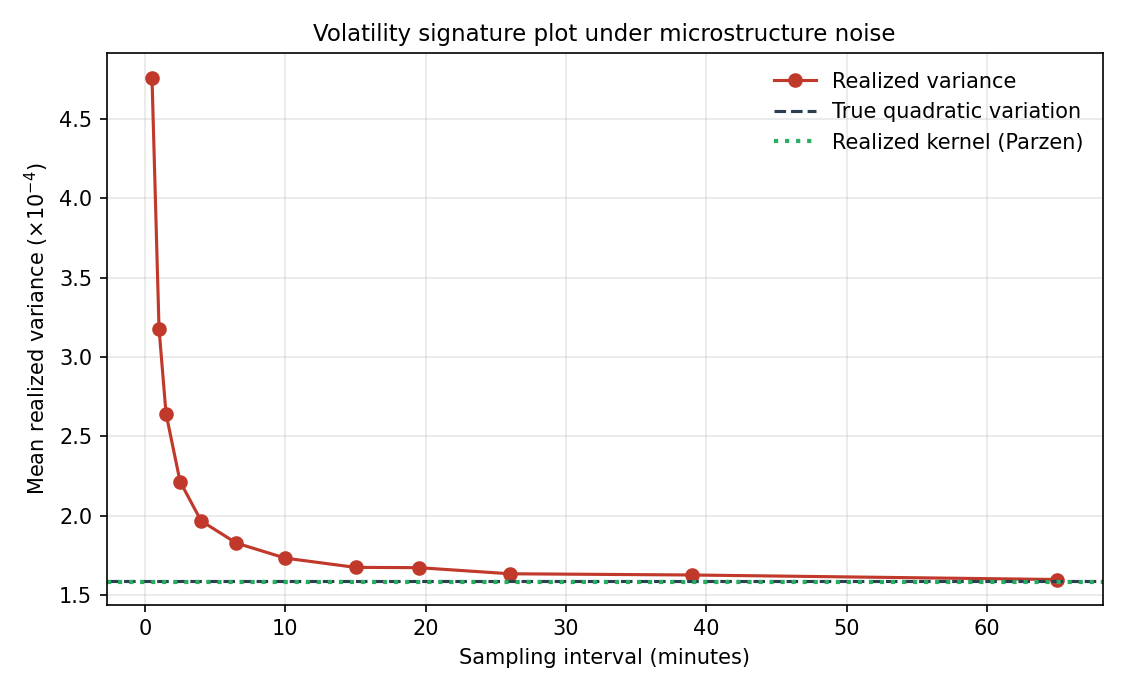

In [4]:
show('signature_plot.png')

## 3. The model-comparison machinery, built from scratch

The whole point is *statistical significance*, so the tests are implemented from scratch and cross-checked against statsmodels, scipy and arch in the test suite (DM and Clark-West agree to about 1e-10):

- **Diebold-Mariano**, with a Newey-West HAC long-run variance and the Harvey-Leybourne-Newbold small-sample correction (and the horizon-aware lag that a multi-step forecast needs).
- The **Model Confidence Set** (Hansen-Lunde-Nason 2011), using the range statistic with a moving-block bootstrap.
- **Clark-West** for nested models, where standard Diebold-Mariano is not valid.

Here is the actual Diebold-Mariano implementation (78 lines, no black box):

In [5]:
print(inspect.getsource(__import__("volbench.evaluation", fromlist=["diebold_mariano"]).diebold_mariano))

def diebold_mariano(
    loss_a: np.ndarray,
    loss_b: np.ndarray,
    horizon: int = 1,
    lag: int | None = None,
) -> dict[str, float]:
    """Diebold-Mariano test of equal predictive accuracy.

    Tests the null of equal expected loss between forecast A and forecast B.
    The differential is ``d_t = loss_a_t - loss_b_t``; a *negative* mean
    differential favours A (A has lower loss). The statistic uses a Newey-West
    HAC variance with Bartlett weights and applies the Harvey-Leybourne-Newbold
    (1997) finite-sample correction, comparing the corrected statistic to a
    Student-t distribution with ``n - 1`` degrees of freedom.

    Parameters
    ----------
    loss_a, loss_b : np.ndarray
        Per-observation loss series of equal length.
    horizon : int, default 1
        Forecast horizon ``h``. When ``lag`` is not given, the truncation lag
        defaults to ``h - 1`` (the textbook choice for h-step forecasts).
    lag : int, optional
        Override for the HAC tr

## 4. The headline: log-HAR is hard to beat

Out-of-sample QLIKE (proxy-robust, Patton 2011), eight indices, expanding-window walk-forward (about 5,000 origins per index). Lower is better. **MCS** is the number of indices (out of 8) where the model stays in the 90% Model Confidence Set; **Beats HAR** counts indices where the model is significantly better than the level-HAR benchmark (Diebold-Mariano, 5%).

In [6]:
s = load("summary.json")["by_horizon"]["1"]
lb = pd.DataFrame({
    "Avg QLIKE": s["avg_qlike"],
    "Avg rank": s["avg_rank"],
    "MCS (of 8)": s["mcs_count"],
    "Beats HAR": s["dm_beats_har"],
}).sort_values("Avg QLIKE").round(3)
lb

,Avg QLIKE,Avg rank,MCS (of 8),Beats HAR
LogHAR,0.187,1.125,8,6
GBRT,0.196,2.750,1,2
ARFIMA,0.197,2.750,0,4
HAR,0.198,3.375,2,0
AR1Log,0.239,5.500,0,0
EWMA,0.244,5.875,0,0
MA22,0.262,7.000,0,0
RW,0.468,7.750,0,0
HistMean,0.651,8.875,0,0


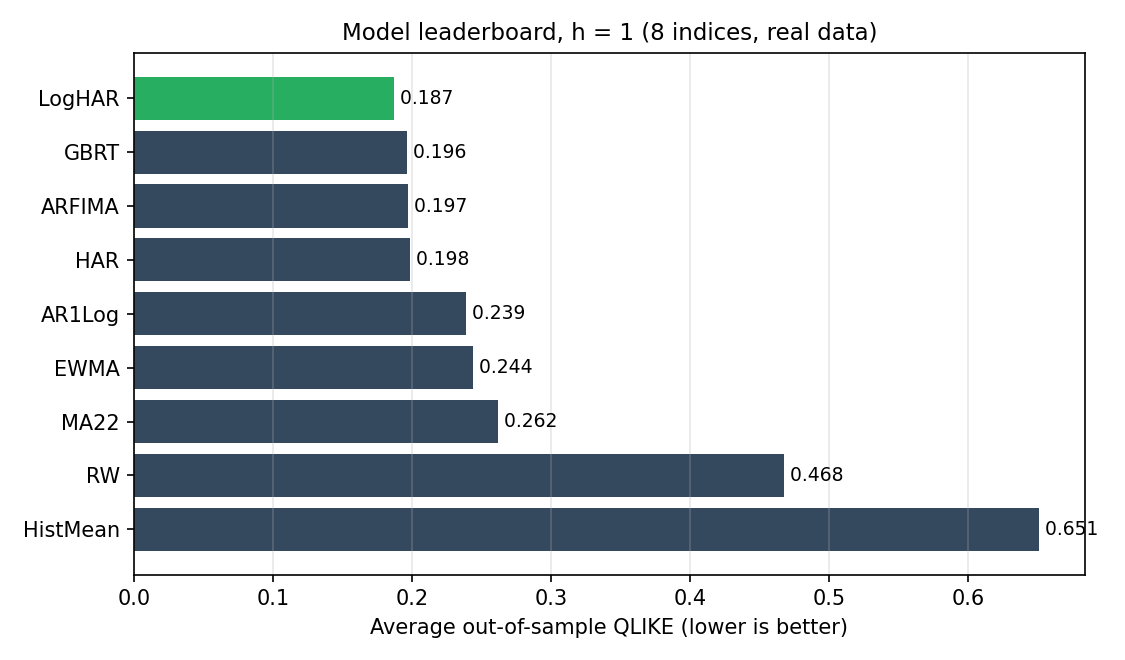

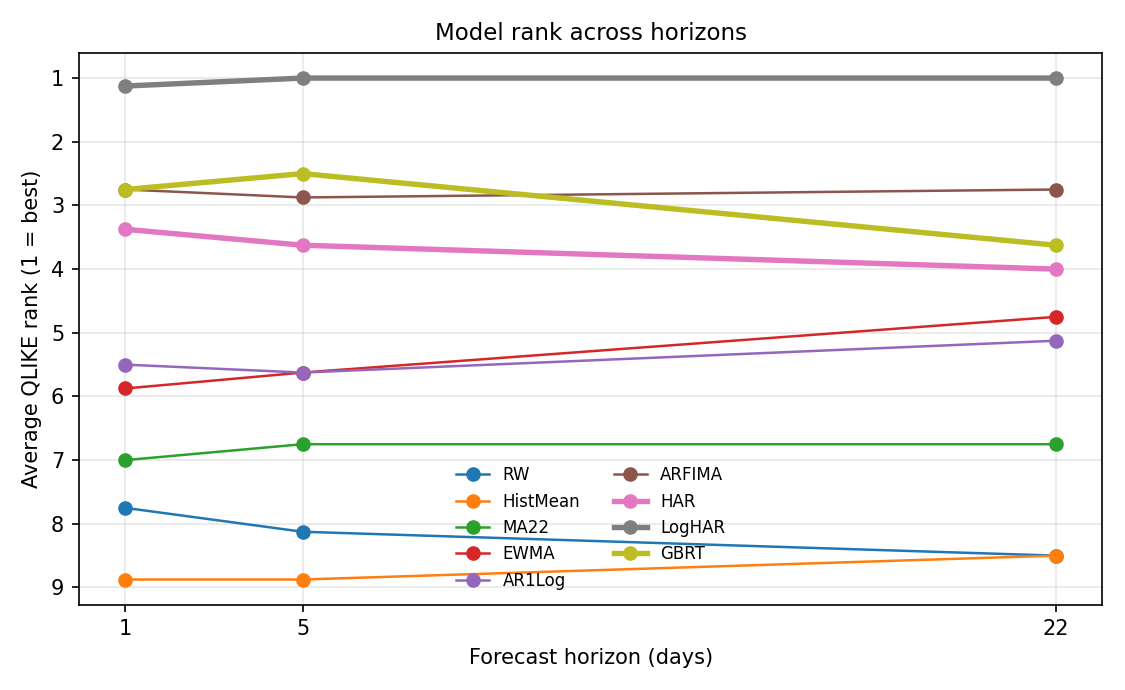

In [7]:
show('leaderboard_h1.png')
show('qlike_by_horizon.png')

log-HAR is rank-1 and in the Model Confidence Set for all eight indices at every horizon (1, 5, 22 days). Modelling log-variance, which respects positivity and the heavy right tail of variance, is worth more than model complexity. The gradient-boosted model and the long-memory ARFIMA are the closest competitors but never displace it.

## 5. Proof it runs: a live walk-forward

The whole pipeline is one call. Here it runs end to end on the S&P 500 and reports which models survive in the 90% Model Confidence Set.

In [8]:
try:
    from volbench.data import load_oxford_rv
    from volbench.backtest import run_backtest
    rv = load_oxford_rv().series(".SPX")
    res = run_backtest(rv, horizon=1, mcs_reps=300)
    ranking = sorted(res.mean_losses["QLIKE"].items(), key=lambda kv: kv[1])
    print("Out-of-sample QLIKE ranking (.SPX, h=1):")
    for name, q in ranking:
        print(f"  {name:10s} {q:.4f}")
    print("\nModels in the 90% MCS:", sorted(res.mcs["QLIKE"].included))
except FileNotFoundError:
    print("Oxford-Man data not present locally; run scripts/build_realized.py to fetch it.")

Out-of-sample QLIKE ranking (.SPX, h=1):
  LogHAR     0.2060
  ARFIMA     0.2160
  GBRT       0.2229
  HAR        0.2255
  AR1Log     0.2354
  RW         0.2892
  EWMA       0.2974
  MA22       0.3195
  HistMean   0.8277

Models in the 90% MCS: ['LogHAR']


## 6. Does machine learning win? No.

LightGBM and XGBoost, fit in log-variance space with **leakage-free expanding-window hyperparameter tuning**, on a plain HAR feature set and an enriched one (continuous/jump split plus realized semivariances). Even with a fair quarterly refit and richer features, no ML model displaces log-HAR, and a log-HAR + ML combination does not beat log-HAR alone. This is the cleanest form of the "structure beats flexibility" result, reported rather than tuned away.

In [9]:
m = load("ml.json")["by_horizon"]["1"]
ml = pd.DataFrame({
    "Avg rank": m["avg_rank"],
    "Avg QLIKE": m["avg_qlike"],
    "MCS (of 8)": m["mcs_count"],
}).sort_values("Avg rank").round(3)
ml

,Avg rank,Avg QLIKE,MCS (of 8)
Combo,1.375,0.186,7
LogHAR,1.625,0.187,7
XGB-enriched,3.000,0.195,3
LGBM-enriched,4.250,0.206,0
LGBM-plain,4.750,0.211,0


## 7. Where does it break? An honest, pre-registered answer

The distinctive question is the next one: *does it generalise, and where does it stop winning?* It is answered under an internal, pre-specified, falsifiable protocol, so the result cannot be quietly reframed after the fact. The deliverable is the **Q5 cross-asset transfer matrix**: where a HAR-family model stays in the 90% Model Confidence Set, by asset class and horizon.

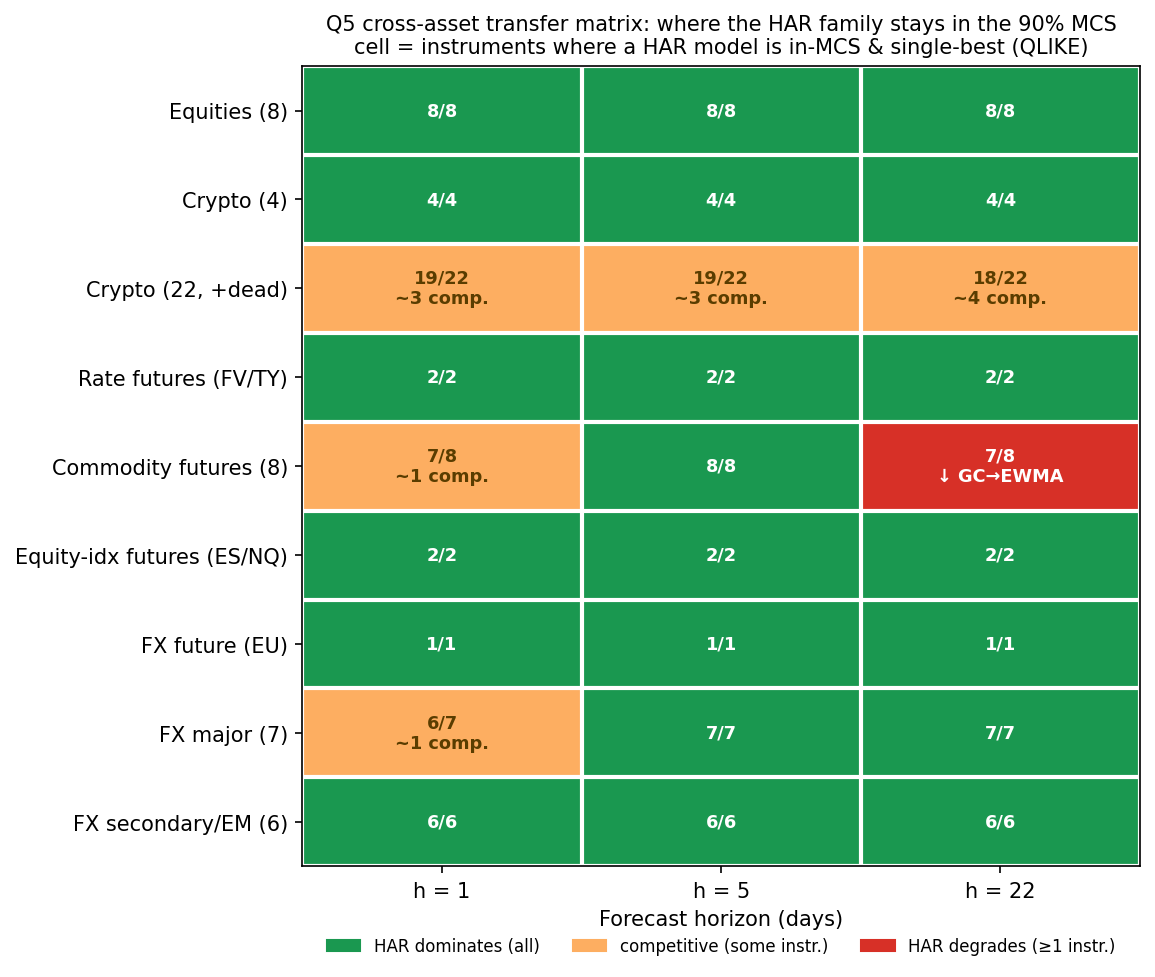

In [10]:
show('transfer_matrix.png')

**Robust replication with narrow cracks.** A HAR-family model is in the 90% MCS and single-best across 8/8 equities, 37/39 futures cells (rates, commodity, equity-index, FX futures), 38/39 FX cells (majors + EM/secondary), and surviving major crypto. Two honest results the protocol named in advance:

- The **primary pre-registered prediction was falsified.** The bet was that rates futures would break HAR (the hypothesized driver being FOMC and auction jumps). They did not; HAR dominates both at every horizon. This is logged as a falsified prediction, not reframed.
- The only genuine degrade is **gold at the monthly horizon** (the single red cell), where a parameter-light EWMA wins. It is adversarially robust but isolated and partly mechanical.

The contribution here is breadth, rigor, and honest negatives, not a new model.

## 8. From forecast to money

A good realized-variance forecast is not alpha by itself; it monetises through the variance risk premium and through risk control, reported with honest accounting (overlap, transaction costs, deflated and probabilistic Sharpe).

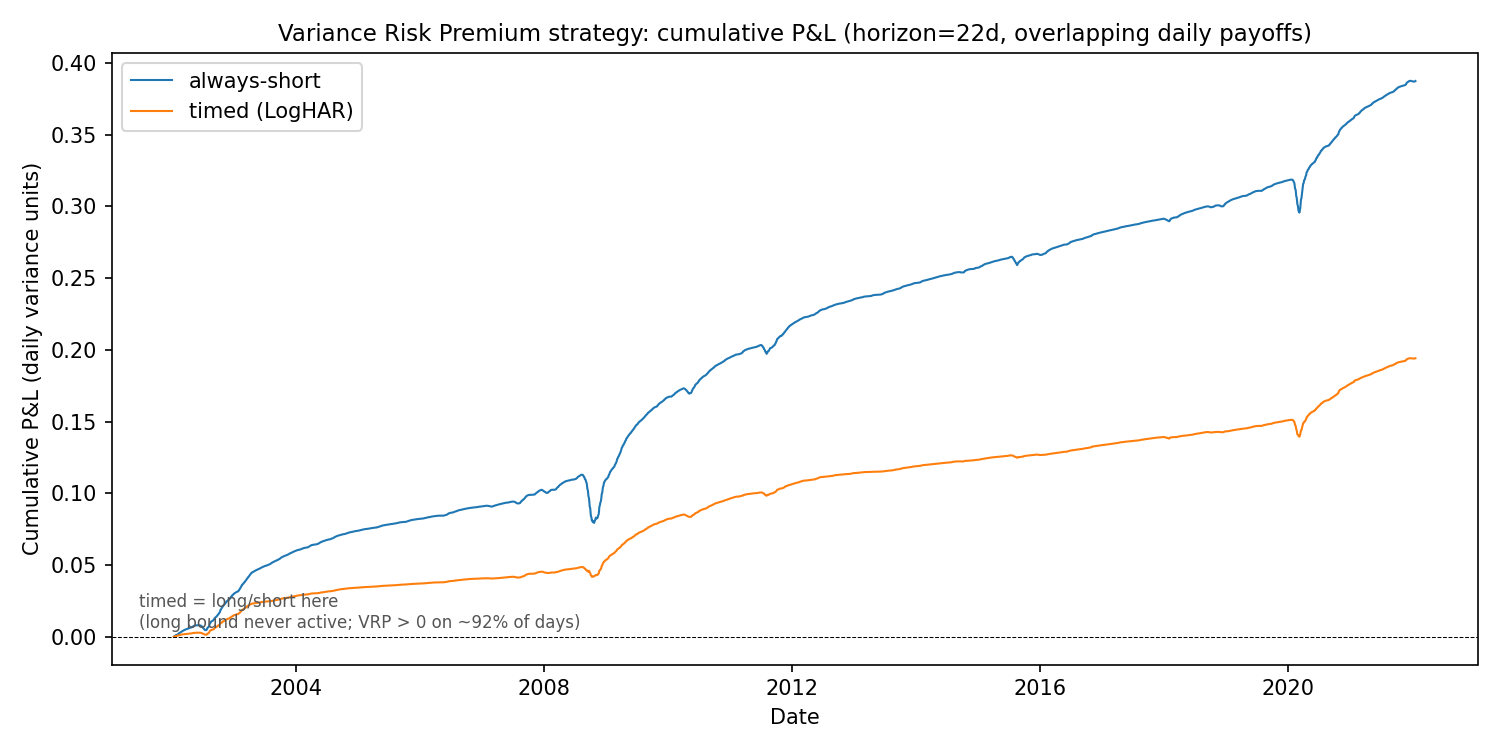

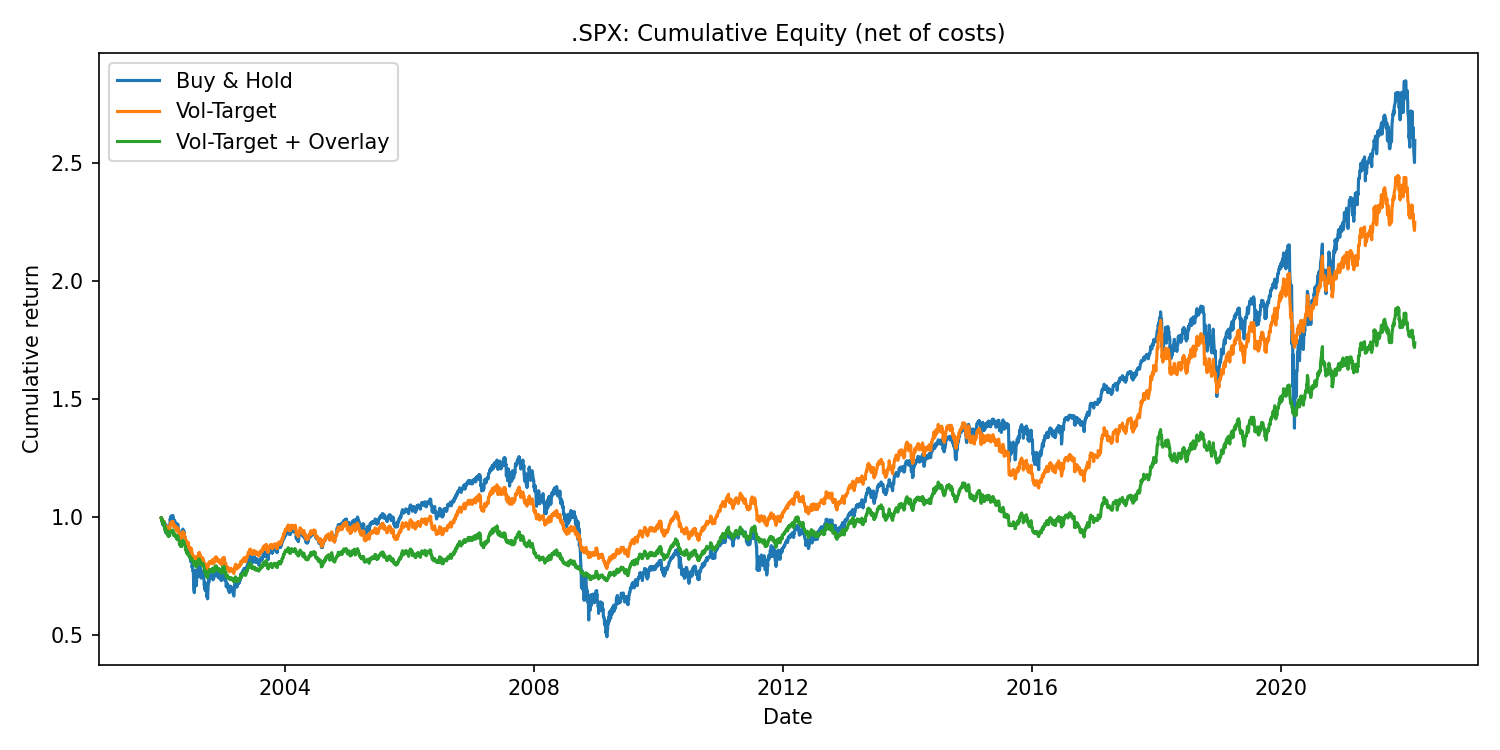

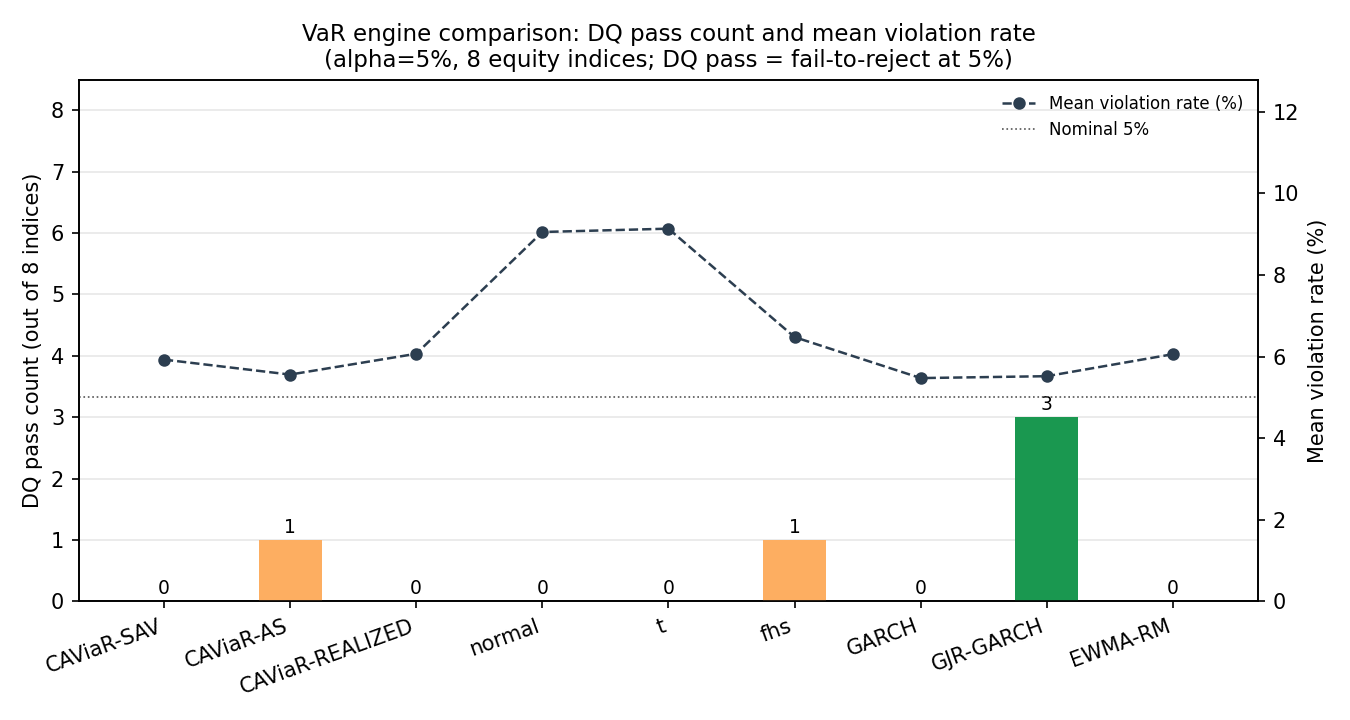

In [11]:
show('vrp.png')
show('strategy.png')
show('var_dq.png')

- **Variance risk premium.** On the S&P 500, implied volatility (VIX 21.5%) sits above realized (16.3%), and the premium is positive 92% of days. Timing the short-variance book with the log-HAR forecast lifts the risk-adjusted return and cuts maximum drawdown by about 65%. On honest non-overlapping payoffs the per-swap Sharpe is about 0.39, and the edge survives a Deflated Sharpe test.
- **Volatility targeting.** Scaling exposure by `target_vol / forecast_vol` (net of costs) cuts maximum drawdown by 20-49% versus buy-and-hold, but improves the Sharpe ratio only on the US indices. Reported honestly: a risk-control tool, not free alpha.
- **Value-at-risk.** A direct-quantile CAViaR layer compared on a common window against the GARCH family. The leverage-aware GJR-GARCH is the best engine (dynamic-quantile test passed on 3 of 8 indices); full conditional-quantile adequacy stays unsolved, and that is reported as an open problem.

## 9. Generality: crypto

Realized measures computed from real Binance 5-minute bars (BTC/ETH/BNB/SOL), so the full estimator suite, including realized quarticity, runs on real data. log-HAR is rank-1 and in the MCS for all four coins at every horizon: the headline survives a 24/7, fat-tailed asset class. The real-data signature plot below (anchored to the research date, 2026-06-23) shows the same microstructure-noise inflation at high frequency as the simulation in Section 2, here on genuine BTC data.

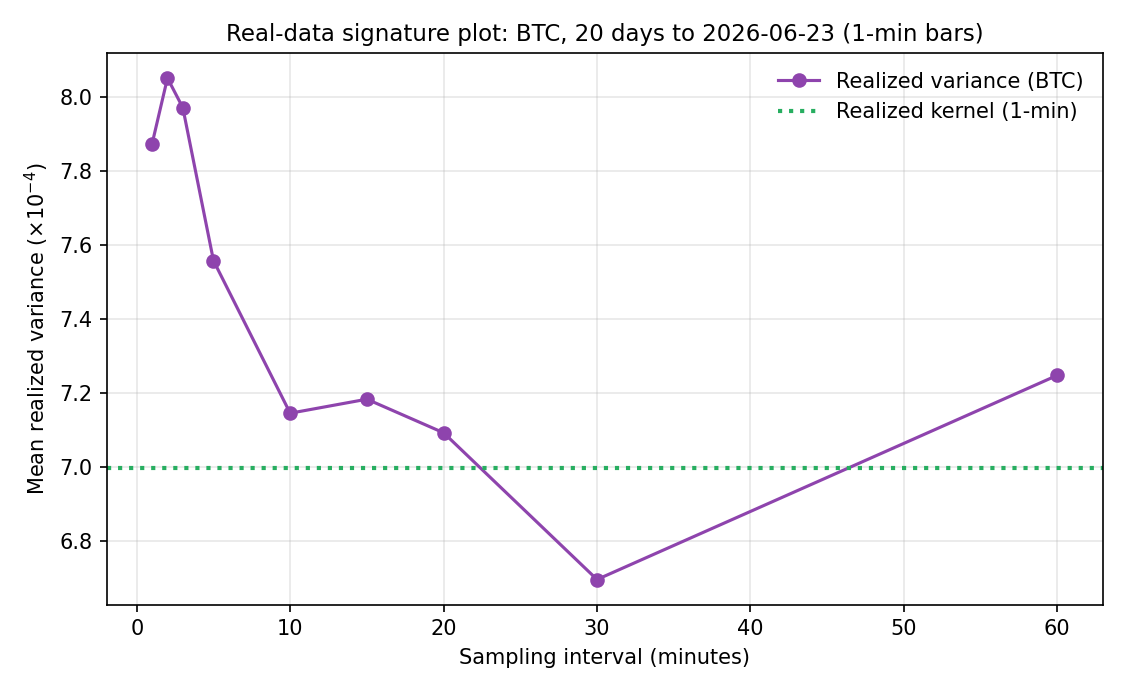

In [12]:
show('crypto_signature.png')

## What I built, and why it matters

**Implemented from scratch:** the Model Confidence Set, Diebold-Mariano + HLN, and the Clark-West nested test; the look-ahead-free expanding-window backtest harness; all realized estimators (bipower variation, realized kernel, semivariances, quarticity, BNS jump test); and the value-at-risk and variance-risk-premium layers. I set the research questions, the pre-specified decision rules, and did all result interpretation. Implementation used AI coding assistance; every statistical result is reproducible from the committed code and a fixed seed.

**Skills demonstrated:** time-series econometrics (HAR, GARCH, realized volatility), hypothesis testing and the bootstrap, value-at-risk (CAViaR, GJR-GARCH, Kupiec / Christoffersen / dynamic-quantile), the variance risk premium and volatility targeting, and the engineering around it (Python, NumPy, pandas, scikit-learn, statsmodels, arch, LightGBM/XGBoost, 245 tests, CI with ruff + mypy + pytest, full reproducibility).

**Why it is hard:** look-ahead bias at horizons beyond one day, proxy-robust loss functions, choosing nested versus non-nested significance tests correctly, and validating microstructure estimators against known ground truth. The honest, pre-registered negative on cross-asset generalisation is the part most projects skip.

Repository: [github.com/batuhanboztepe0/volbench](https://github.com/batuhanboztepe0/volbench)